In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
#np.random.seed(42) # reproducibility

# Générer N échantillons aléatoirs depuis la distribution de Poisson avec une moyenne lambda
lambda_value = 10 # moyenne
N = 10000 # Nb de données de la population générée
DataPopulation = np.random.poisson(lam = lambda_value, size = N) # Pop. où l'on souhaite déterminer/approx. les paramètres de distribution

# Obtenir une sous population de n échantillons depuis Datapopulation
n = 200
DataSample = np.random.choice(DataPopulation, size=n,replace=False) # Choisis aléatoirement dans Datapop n echantillons sans les remplacer
# => si pas remplacés, sont enlevé de la population /!\ peut changer la distribution de la population si petite population.

# Calculer la moyenne et la variance des  deux vecteurs
# Pop.
mean_population = np.mean(DataPopulation) 
std_population = np.std(DataPopulation)

#Sample
mean_sample = np.mean(DataSample)
std_sample = np.std(DataSample)

# Résultats
print(f"Moyenne population {mean_population}")
print(f"Variance population {std_population}")

print(f"Moyenne echantillon {mean_sample}")
print(f"Variance echantillon {std_sample}")

Moyenne population 10.0401
Variance population 3.1943844461805155
Moyenne echantillon 9.62
Variance echantillon 3.271941319767211


Les moyennes sont relativements proches, les variances un peu moins

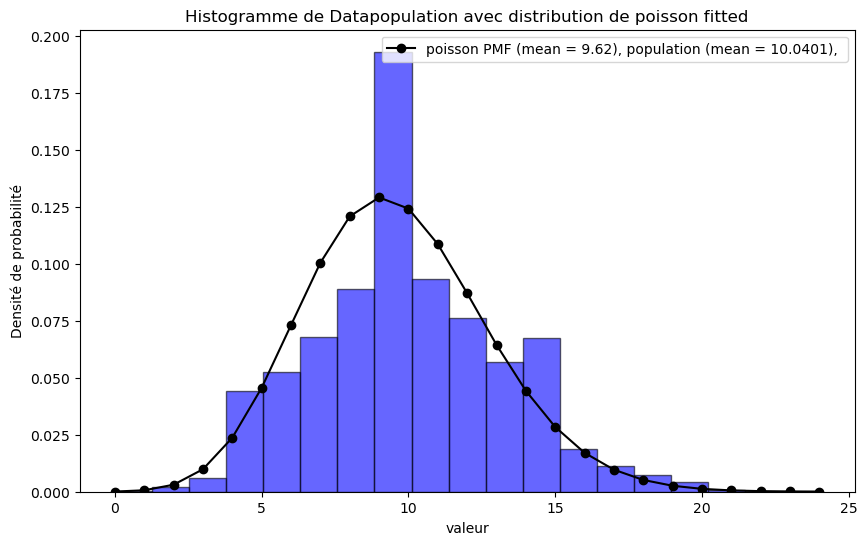

In [27]:
from scipy.stats import poisson

#Hist de datapop
plt.figure(figsize=(10,6))
counts, bins, _ = plt.hist(DataPopulation, bins=19, color='blue', edgecolor='black', alpha=0.6, density=True)

# Distribution de Poisson qui fit au mieux la moyenne des échantillons
x = np.arange(0, bins[-1]+1) # Même nombre de bins
pmf_values = poisson.pmf(x, mu= mean_sample) 
plt.plot(x, pmf_values, 'k-', marker='o', label = f"poisson PMF (mean = {mean_sample:.2f}), population (mean = {mean_population}), ")

#labels
plt.xlabel('valeur')
plt.ylabel('Densité de probabilité')
plt.title('Histogramme de Datapopulation avec distribution de poisson fitted')

plt.legend()
plt.show()

In [28]:
# Debug -> J'avais pas mis density = True dans plt.hist
print(f"{np.mean(pmf_values):.2f}")
print(np.mean(DataPopulation))

print(bins.shape)
print(x.shape)
print(bins)
print(x)

0.04
10.0401
(20,)
(25,)
[ 0.          1.26315789  2.52631579  3.78947368  5.05263158  6.31578947
  7.57894737  8.84210526 10.10526316 11.36842105 12.63157895 13.89473684
 15.15789474 16.42105263 17.68421053 18.94736842 20.21052632 21.47368421
 22.73684211 24.        ]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24.]


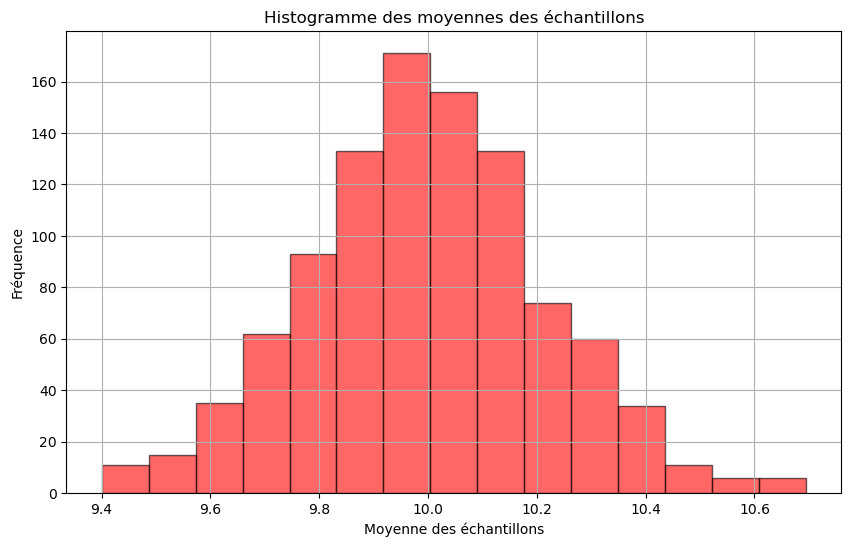

In [29]:
#np.random.seed(42) # reproducibility

# Générer N échantillons aléatoirs depuis la distribution de Poisson avec une moyenne lambda
lambda_value = 10 # moyenne
N = 10000 # nb d'echantillons
DataPopulation = np.random.poisson(lam = lambda_value, size = N)

# Obtenir une sous population aléatoire de n échantillons depuis Datapopulation m fois
lambda_value = 10
n = 200 # nb d'ech.
m=1000 # nb de tirages de n ech.

# Initialisation des array pour stocker les valeurs de moyenne et de variance des  echantillons
SampleMeans = np.zeros(m) # m ech
SampleSTD = np.zeros(m)

for i in range(m):
    # Prend n echantillons de Datapop, calcul la moyenne et l'écart-type pour m tirage aléatoire de n ech. 
    DataSample = np.random.choice(DataPopulation, size = n, replace= False)
    SampleMeans[i]=np.mean(DataSample)
    SampleSTD[i]=np.std(DataSample)

# plot
plt.figure(figsize=(10,6))
plt.hist(SampleMeans, bins = 15, color='red',edgecolor='black', alpha =0.6)
plt.title('Histogramme des moyennes des échantillons')
plt.xlabel('Moyenne des échantillons')
plt.ylabel('Fréquence')
plt.grid()
plt.show()

In [30]:
print(np.mean(SampleMeans))
print(np.std(SampleMeans))

9.998145000000001
0.217157854969605


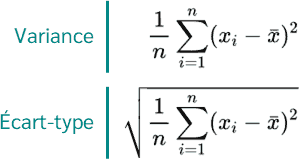

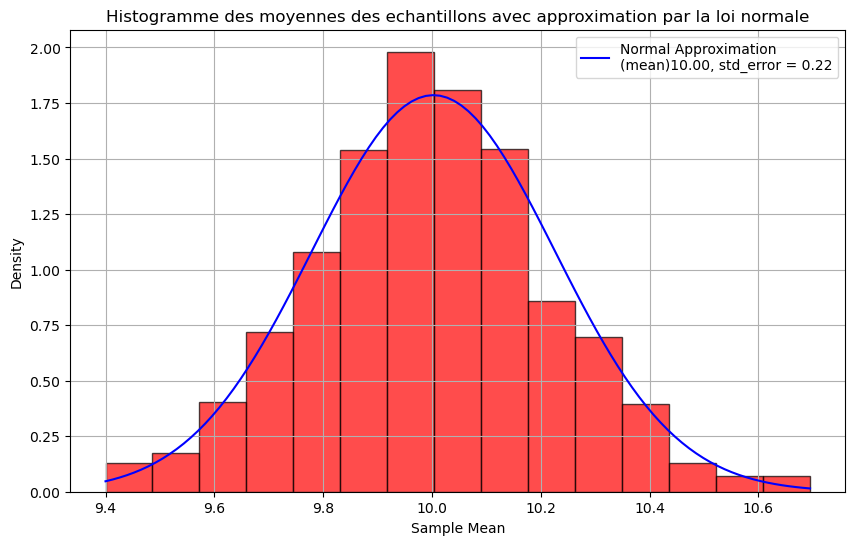

In [31]:
from scipy.stats import norm

mean_population = np.mean(DataPopulation)
std_population = np.std(DataPopulation)

# Calculer la variance des moyennes des  echantillons ( Standard error of the mean )
std_error = std_population/np.sqrt(n) # rappel variance est le carré de l'écart-type
# Si on met au carré => Variance de l'erreur  = variance_population / n 
# => Plus n est grand, plus la variance de l'erreur diminue => 
#Quand n tend vers N (nombre de point de la popu) la moyenne des echantillon tendent à suivre la loi normale de la population
# => théorème de limite centrale

# Génération de la distribution normale qui approche la distribution des moyennes des echantillons
x = np.linspace(min(SampleMeans), max(SampleMeans), 100) # x => 100 points linéairement espacés entre le min etr le max de samplemeans
normal_approximation = norm.pdf(x, loc = mean_population, scale=std_error) # x sert à connaître l'interval linéaire sur x sur lequel on va réaliser l'approx.
# loc => centrée en mean_population et sclale = écart-type de la loi normale

# Tracer hist de samplemeans
plt.figure(figsize=(10,6))
plt.hist(SampleMeans, bins = 15, color='red', edgecolor='black', alpha=0.7, density=True)

# Tracé de la loi normale approx
plt.plot(x, normal_approximation,'b',label=f'Normal Approximation\n(mean){mean_population:.2f}, std_error = {std_error:.2f}')

plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title('Histogramme des moyennes des echantillons avec approximation par la loi normale')

plt.legend()
plt.grid()
plt.show()


pdf = Probability Density Function
pmf = Probability Mass Function
cdf = Cumulative Distribution Function

pmf sert pour des variables discrètes (ex. : nombre de succès, nombre de clients) ;

pdf sert pour des variables continues (ex. : taille, poids, temps) ;

cdf donne la probabilité d’avoir une valeur inférieure ou égale à un seuil.

Exemples :

Pour une loi de Poisson, on utilise pmf parce que la variable prend des valeurs entières.

Pour une loi normale, on utilise pdf parce que la variable peut prendre une infinité de valeurs continues.

Pour connaître la probabilité qu’une valeur soit inférieure à 5, on utilise cdf.

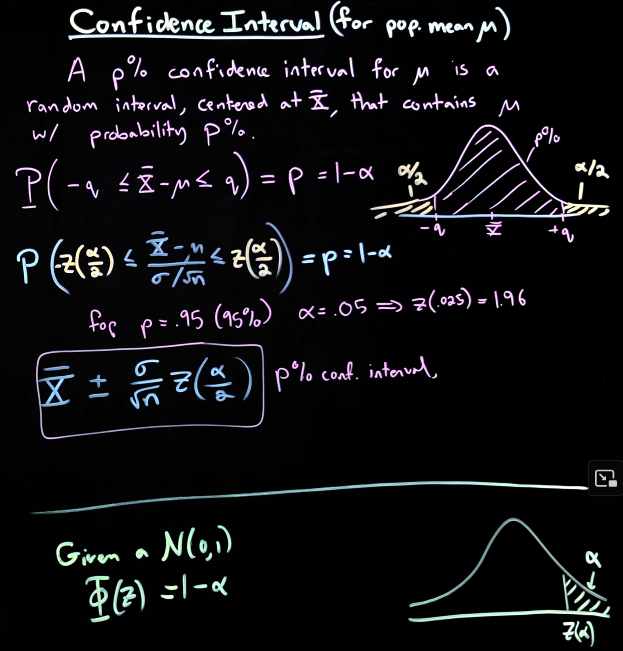

In [32]:
# Interval de confiance : X_mean +- std/sqrt(n) * Z(alpha/2)
# Je veux alpha = 0.5 % => alpha/2 = 0.25 => z(0.25) = 1.96

# Dans le cas où on a pas std_population, on remplace par approx

# Depuis notes : approx std_pop = std_sample/sqrt(n) * (sqrt(1 - n/N))

# z(alpha/2) est calculable à partir de la distribution cumulée normale

print(f"x_mean = {mean_sample} +- {(std_population/np.sqrt(n)) * 1.96} \noù la moyenne de la population tombe à 95 % du temps dans cet interval à chaque échantillonnage")
print(f"approx de std_pop x_mean = {mean_sample} +- {(std_sample/np.sqrt(n) * ((np.sqrt(1-n/N)))/np.sqrt(n)) * 1.96}")

x_mean = 9.62 +- 0.43798638879956076 
où la moyenne de la population tombe à 95 % du temps dans cet interval à chaque échantillonnage
approx de std_pop x_mean = 9.62 +- 0.03174275519736747


In [33]:
# approx

std_pop_approx = std_sample/np.sqrt(n) * (np.sqrt(1-n/N))

print(f"std_pop_approx = {std_pop_approx} : std_pop = {std_population}")

std_pop_approx = 0.22903589238370475 : std_pop = 3.160236179465073


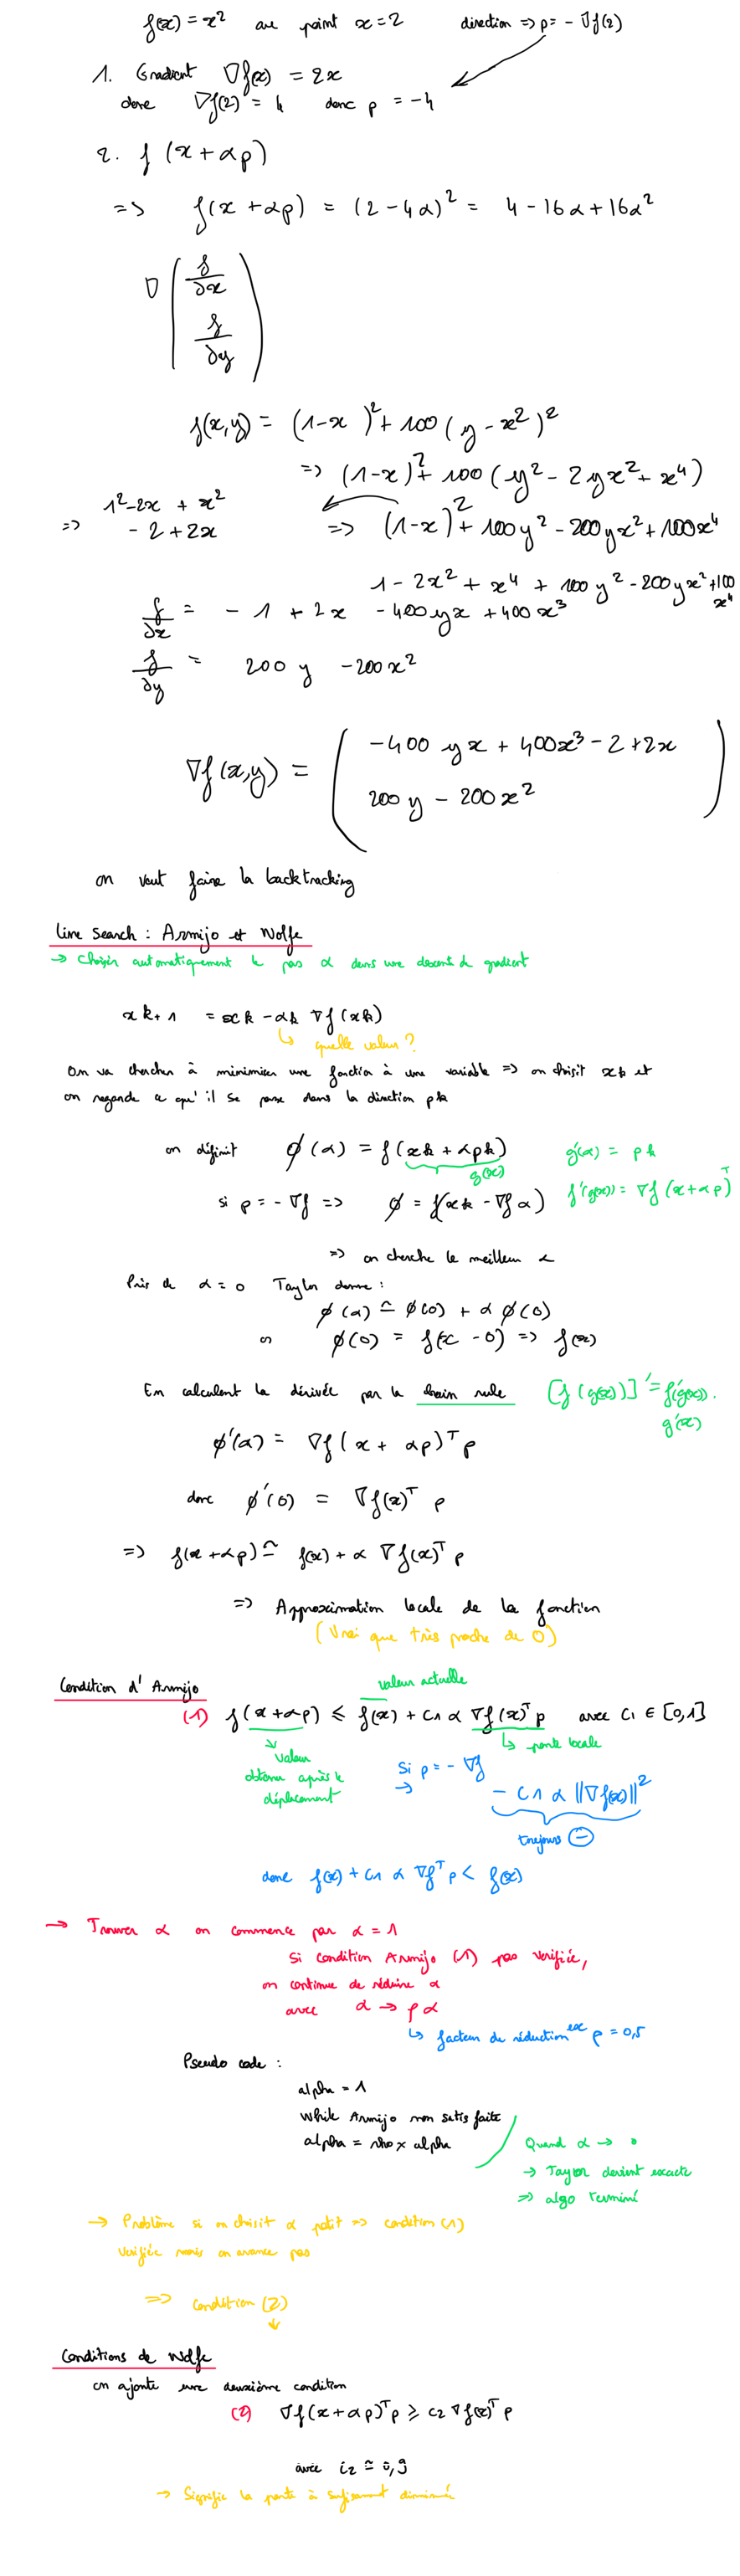

In [36]:
# backtracking sur Rosenbrock
# fonction de Rosenbrock

import numpy as np

X = np.array([1,1])

print(f"x = {X[0]}, y = {X[1]}")

def rosenbrock(X):
    x = X[0]
    y = X[1]
    return np.array([((1-x)**2+100*(y-x**2)**2)])

def grad_rosenbrock(X):
    x = X[0]
    y = X[1]
    return np.array([-400*x*y+400*x**3-2+2*x,
            200*y-200*x**2])

print(rosenbrock(X))
print(grad_rosenbrock(X))

x = 1, y = 1
[0]
[0 0]


In [37]:
# La méthode d'optimisation => la direction p
# le backtracking => le meilleur pas alphale long de cette direction

def backtracking_line_search(rosenbrock, grad_rosenbrock,X,p, alpha=1.0,rho=0.5,c1=1e-4):
    '''Avec x le point courant,  alpha le pas initial, rho le facteur de diminution et c1 la constante d'Armijo'''
    #bool_Armijo = (rosenbrock(X+alpha*p)<=rosenbrock(x)+c1*alpha*np.dot(grad_rosenbrock,p))
    #bool_Wolfe is True if (grad_rosenbrock(X+alpha*p)*p>=c2*grad_rosenbrock(X)*p) else False
    itter = 0
    fx = rosenbrock(X)
    g = grad_rosenbrock(X)
    gTp = g @ p

    while rosenbrock(X+alpha*p) > fx+c1*alpha*gTp:
        alpha = rho*alpha
        itter += 1
    print(f"{itter} itteration")
    return alpha

X = np.array([-1.2,1])
p = -grad_rosenbrock(X)

alpha = backtracking_line_search(rosenbrock, grad_rosenbrock, X,p)

print("Gradient :", grad_rosenbrock(X))
print("Direction :", p)
print("alpha :", alpha)


10 itteration
Gradient : [-215.6  -88. ]
Direction : [215.6  88. ]
alpha : 0.0009765625
